# EDA — Clasificador de eventos SoccerNet (Fase 1)

Análisis exploratorio del dataset de ventanas construido en la Fase 1
(**camino liviano**: `Labels-v2.json` + features ResNet pre-extraídas, sin frames).

**Invariante del proyecto:** este notebook **solo consume desde `src/`** — no
reimplementa lógica de datos ni de features. Carga el manifest y las features
pooled vía `src.data.dataset.load_dataset`.

Objetivo del EDA (requerimiento mínimo de la consigna): entender la distribución
de clases, el **desbalance** (invariante 5: `background` domina), y la cobertura
de los splits, para fundamentar las decisiones de modelado de la Fase 2.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Ubicar la raíz del repo (contiene configs/dataset.yaml) y exponer `import src`.
here = Path.cwd()
root = next(p for p in [here, *here.parents] if (p / "configs" / "dataset.yaml").is_file())
sys.path.insert(0, str(root / "backend"))

from src.data.config import DatasetConfig
from src.data.dataset import load_dataset

sns.set_theme(style="whitegrid")
cfg = DatasetConfig.from_yaml(root / "configs" / "dataset.yaml")
manifest, features = load_dataset(cfg)
summary = json.loads((root / cfg.paths.summary_file).read_text(encoding="utf-8"))
print(f"{len(manifest)} ventanas, features {features.shape}, {summary['n_games']} partidos")
manifest.head()

Matplotlib is building the font cache; this may take a moment.


615 ventanas, features (615, 512), 8 partidos


,window_id,game_id,split,label,position_ms,half,minute,score_diff,league,team_is_home,visible,events_so_far,secs_since_last_event
0,0,england_epl/2014-2015/2015-02-21 - 18-00 Chels...,val,corner,182775,1,3,0,england_epl,0,1,4,26.677
1,1,england_epl/2014-2015/2015-02-21 - 18-00 Chels...,val,corner,292492,1,4,0,england_epl,1,1,9,20.741
2,2,england_epl/2014-2015/2015-02-21 - 18-00 Chels...,val,corner,667482,1,11,0,england_epl,1,0,27,6.743
3,3,england_epl/2014-2015/2015-02-21 - 18-00 Chels...,val,goal,790722,1,13,0,england_epl,1,1,31,41.483
4,4,england_epl/2014-2015/2015-02-21 - 18-00 Chels...,val,corner,880053,1,14,1,england_epl,1,1,35,10.769


## 1. Distribución de clases y desbalance

La consigna exige manejar el desbalance explícitamente (nunca reportar accuracy a secas).

label
background      410
corner          104
substitution     45
card             33
goal             23
Name: count, dtype: int64

Ratio de desbalance (mayoritaria/minoritaria): 17.8x
Proporción background: 66.7%


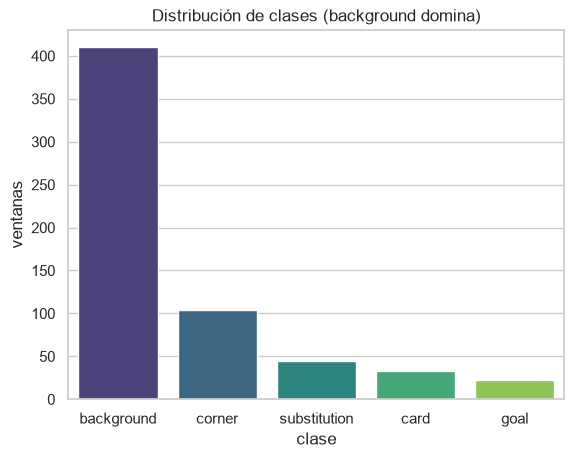

In [2]:
class_order = ["background", "corner", "substitution", "card", "goal"]
counts = manifest["label"].value_counts().reindex(class_order)
imbalance = counts.max() / counts.min()
print(counts)
print(f"\nRatio de desbalance (mayoritaria/minoritaria): {imbalance:.1f}x")
print(f"Proporción background: {counts['background'] / counts.sum():.1%}")

ax = sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="viridis", legend=False)
ax.set(title="Distribución de clases (background domina)", xlabel="clase", ylabel="ventanas")
plt.show()

## 2. Eventos por minuto y mitad

¿Hay sesgos temporales? (ej. más sustituciones al final, más córners en ciertas franjas).

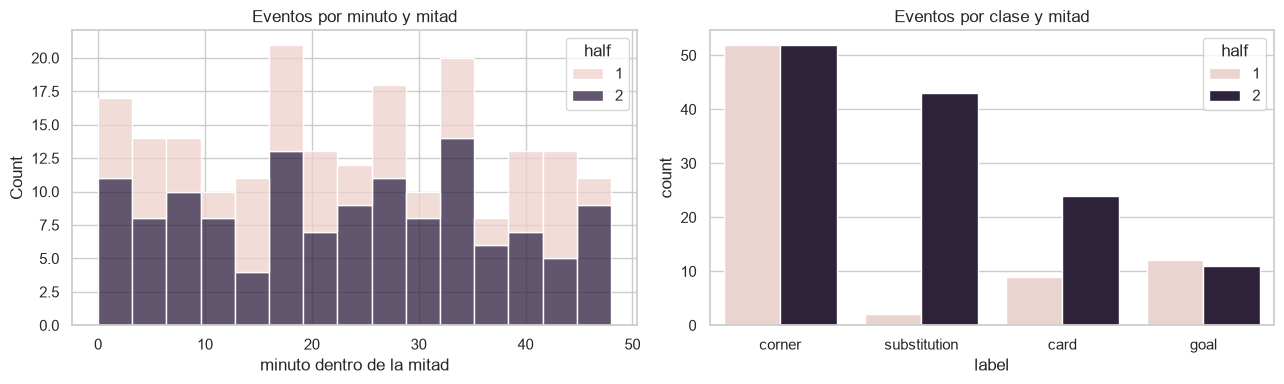

In [3]:
ev = manifest[manifest["label"] != "background"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(ev, x="minute", hue="half", multiple="stack", bins=15, ax=axes[0])
axes[0].set(title="Eventos por minuto y mitad", xlabel="minuto dentro de la mitad")
sns.countplot(ev, x="label", hue="half", order=["corner", "substitution", "card", "goal"], ax=axes[1])
axes[1].set(title="Eventos por clase y mitad")
plt.tight_layout(); plt.show()

## 3. Cobertura por split (sanity de la partición por game_id)

Los splits son por partido (invariante 1). Con pocos partidos, val/test tienen cobertura fina por clase: lo verificamos para no llevarnos sorpresas en la evaluación de Fase 2.

Ligas presentes: ['england_epl'] → subconjunto chico de una sola liga (limitación asumida; se diversifica al escalar)
label  background  corner  substitution  card  goal
split                                              
test           48      11             6     4     3
train         264      65            29    23    15
val            98      28            10     6     5


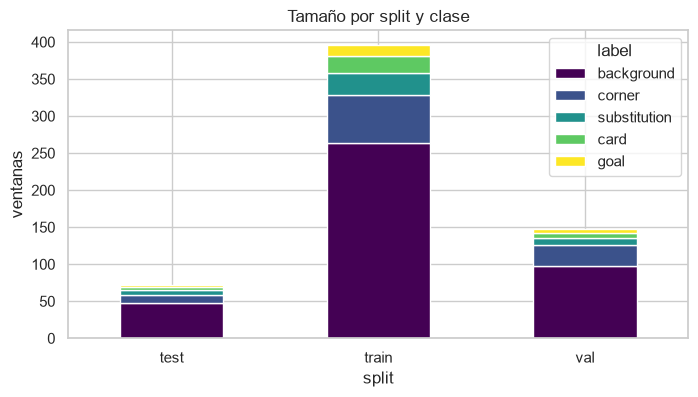

In [4]:
print("Ligas presentes:", list(manifest["league"].unique()),
      "→ subconjunto chico de una sola liga (limitación asumida; se diversifica al escalar)")
pivot = manifest.pivot_table(index="split", columns="label", values="window_id",
                             aggfunc="count", fill_value=0).reindex(columns=class_order)
print(pivot)
pivot.plot(kind="bar", stacked=True, colormap="viridis", figsize=(8, 4))
plt.title("Tamaño por split y clase"); plt.ylabel("ventanas"); plt.xticks(rotation=0); plt.show()

## 4. Feature tabular point-in-time: `score_diff`

Distribución de la diferencia de score acumulada (home − away) calculada **solo con goles previos a t** (invariante 2).

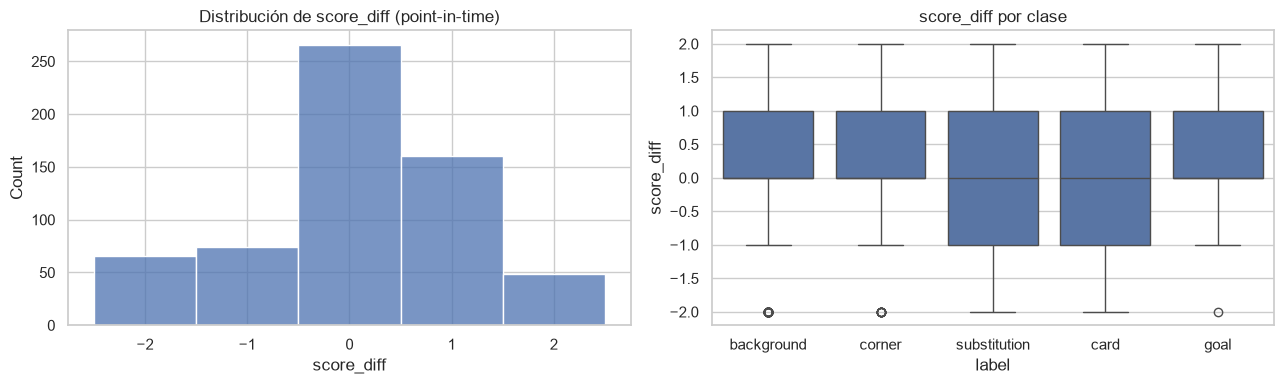

              visible  events_so_far  secs_since_last_event
label                                                      
background       0.00          93.76                  59.86
card             0.94         141.76                  14.22
corner           0.85          96.28                  24.19
goal             1.00         108.13                  12.99
substitution     0.82         154.18                  59.31


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(manifest, x="score_diff", bins=range(-4, 5), discrete=True, ax=axes[0])
axes[0].set(title="Distribución de score_diff (point-in-time)")
sns.boxplot(manifest, x="label", y="score_diff", order=class_order, ax=axes[1])
axes[1].set(title="score_diff por clase")
plt.tight_layout(); plt.show()
print(manifest.groupby("label")[["visible", "events_so_far", "secs_since_last_event"]].mean().round(2))

## 5. Sanity de las features ResNet pooled

Las features son 512-dim (PCA) pooled en la ventana ±2s. Chequeamos que no haya vectores degenerados (norma 0 / NaN).

dim=512  n=615  norma L2: min=12.87 media=23.70 max=40.09
NaNs: 0  vectores nulos: 0


/Users/cdutradasilveira/Documents/ORT/Tercer semestre/ML en producción/Obligatorio/backend/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


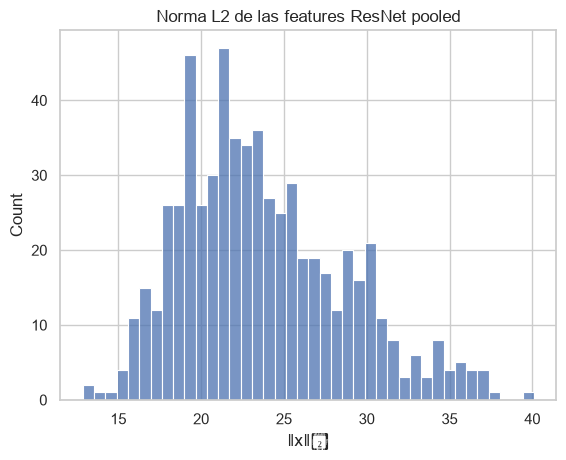

In [6]:
norms = np.linalg.norm(features, axis=1)
print(f"dim={features.shape[1]}  n={features.shape[0]}  "
      f"norma L2: min={norms.min():.2f} media={norms.mean():.2f} max={norms.max():.2f}")
print(f"NaNs: {np.isnan(features).sum()}  vectores nulos: {(norms == 0).sum()}")
sns.histplot(norms, bins=40); plt.title("Norma L2 de las features ResNet pooled"); plt.xlabel("‖x‖₂"); plt.show()

## Hallazgos (Fase 1)

1. **Desbalance fuerte y deliberado.** `background` es ~2/3 de las ventanas (ratio
   2:1 por construcción, no natural). Confirma que en Fase 2 hay que reportar
   **precision/recall/F1 por clase y PR-AUC**, nunca accuracy a secas, y considerar
   `class_weight`/`scale_pos_weight` en el baseline.

2. **Clases minoritarias críticas.** `goal` (~23) y `card` (~33) son las más raras;
   en val/test quedan pocas decenas/unidades por clase. La métrica por clase será
   ruidosa: es una limitación del subconjunto chico (8 partidos, 1 liga), escalable
   subiendo `num_games` en `configs/dataset.yaml`.

3. **Señal temporal aprovechable.** La distribución de eventos por minuto/mitad y la
   feature `score_diff` (point-in-time) muestran estructura → justifican incluir las
   features tabulares además de las visuales en el baseline (late fusion).

4. **Features ResNet sanas.** Sin NaNs ni vectores nulos; normas en rango razonable →
   listas para alimentar el modelo v0 (LogReg/XGBoost sobre ResNet pooled ⊕ tabular).

5. **Splits por partido verificados.** La partición es por `game_id` (invariante 1);
   ninguna ventana del mismo partido cruza splits (test de regresión `test_leakage.py`).